# Fine tune sentence transformer 

This notebook implements the steps to finetune the 'all-MiniLM-L6-v2' sentence transformer. It is fine-tuned using the training dataset generated in '1_0_5_rule_based_labelling.ipynb' - which consists of 200,000 pairs of sentences derived from public objections to planning applications. 

The data is loaded directly from the repo on Zenodo: [https://zenodo.org/records/15583249][https://zenodo.org/records/15583249]. Of the 200,000 pairs, 100,000 are positive pairs, and 100,000 are neutral pairs. The positive pairs have soft labels - hence Cosine Similarity is used for training since it works well with floats. 

The model is saved remotely to HuggingFace [https://huggingface.co/Bea-Taylor/objection_fine_tuned][https://huggingface.co/Bea-Taylor/objection_fine_tuned]. The model is evaluated before and after fine tuning. 


In [6]:
import requests
import pickle
from io import BytesIO
import logging

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch
from sentence_transformers import SentenceTransformer, losses, LoggingHandler
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator

# Configure logging
logging.basicConfig(format='%(asctime)s - %(message)s',
                    level=logging.INFO)

### Load data from Zenodo

In [7]:
record_id = "15583249"
access_token = "AUn57Ykztzzg7Cy8MdtAFEzGc53A4StqkVAYehmIa8lXe03evN1rHvV7GwZ6" 

api_url = f"https://zenodo.org/api/records/{record_id}"
headers = {"Authorization": f"Bearer {access_token}"}

# Get metadata
response = requests.get(api_url, headers=headers)
response.raise_for_status()
metadata = response.json()

# Find .pkl file and get the 'self' link
file_url = None
filename = None
for file in metadata.get('files', []):
    if file['key'].endswith('.pkl'):
        filename = file['key']
        file_url = file['links']['self']
        break

if not file_url:
    raise FileNotFoundError("No .pkl file found in the record.")

print(f"Downloading {filename} from {file_url}")

# Download file with auth header
file_response = requests.get(file_url, headers=headers)
file_response.raise_for_status()

# Load pickle from bytes
data = pickle.load(BytesIO(file_response.content))

print("Pickle file loaded:", type(data))


Pickle file loaded: <class 'list'>


### Split into a train and evaluation set

In [8]:
# split a set (10%) out for evaluation
train_pairs, val_pairs = train_test_split(data, test_size=0.1, random_state=42)

# summary stats of train_examples
print(f"Number of training examples: {len(train_pairs)}")

Number of training examples: 180000


### Define baseline model 

In [9]:
model = SentenceTransformer('all-MiniLM-L6-v2')

evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_pairs, name='validation'
)

train_dataloader = DataLoader(train_pairs, shuffle=True, batch_size=64)
train_loss = losses.CosineSimilarityLoss(model=model)

2025-06-03 14:08:24,480 - Use pytorch device_name: cuda:0
2025-06-03 14:08:24,482 - Load pretrained SentenceTransformer: all-MiniLM-L6-v2


In [10]:
# Check if GPU is available and if so move model to GPU
if torch.cuda.is_available():
    model = model.to('cuda')
    print("Using GPU for training")
else:
    print("GPU not available, using CPU")

Using GPU for training


### Define a custom loss-tracking callback function 

In [11]:
class LossLogger:
    def __init__(self):
        self.losses = []
        self.steps = []

    def __call__(self, score, epoch, steps):
        self.losses.append(score)
        self.steps.append(steps)

# Instantiate the callback
loss_logger = LossLogger()

### Evaluate baseline model on the evaluation set 

In [12]:
model.evaluate(evaluator)

2025-06-03 14:08:32,273 - EmbeddingSimilarityEvaluator: Evaluating the model on the validation dataset:
2025-06-03 14:09:38,852 - Cosine-Similarity :	Pearson: 0.3690	Spearman: 0.3635


{'validation_pearson_cosine': 0.3689586166396692,
 'validation_spearman_cosine': 0.3634638764472133}

### Train the model 
With 4 epochs, and 100 warmup steps this takes about 40 minutes to run on the GPU. 

In [13]:
model.fit(train_objectives=[(train_dataloader, train_loss)], 
          epochs=4, 
          warmup_steps=100,
          show_progress_bar=True,
          callback=loss_logger)

Step,Training Loss
500,0.054800
1000,0.020500
1500,0.013600
2000,0.010100
2500,0.008800
3000,0.007400
3500,0.006100
4000,0.005400
4500,0.005100
5000,0.004600


### Plot the loss after training 

In [21]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

event_acc = EventAccumulator('./logs')  # or subdir
event_acc.Reload()

loss_values = event_acc.Scalars('loss')
steps = [x.step for x in loss_values]
loss = [x.value for x in loss_values]

plt.plot(steps, loss)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.grid(True)
plt.show()


ModuleNotFoundError: No module named 'tensorboard'

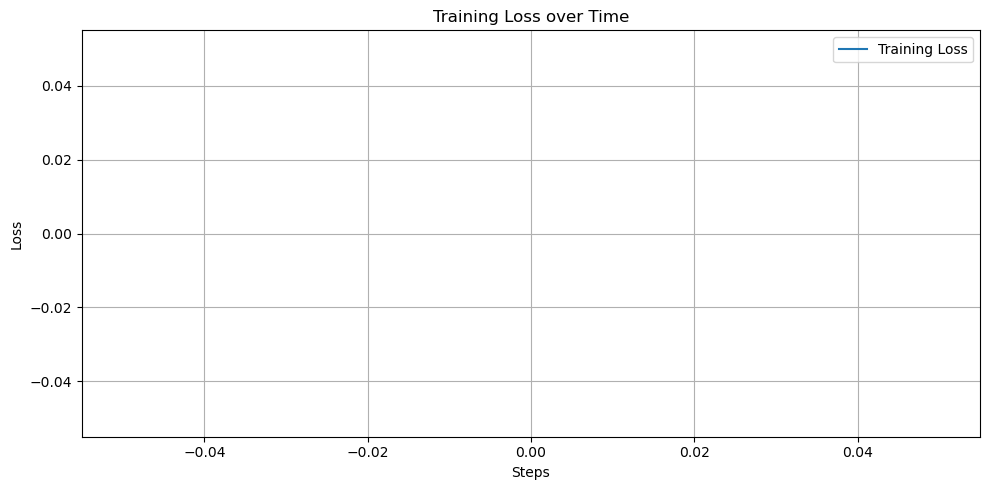

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(loss_logger.steps, loss_logger.losses, label='Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Evaluate the model 

In [15]:
model.evaluate(evaluator)

2025-06-03 14:49:42,451 - EmbeddingSimilarityEvaluator: Evaluating the model on the validation dataset:
2025-06-03 14:50:00,995 - Cosine-Similarity :	Pearson: 0.9903	Spearman: 0.9212


{'validation_pearson_cosine': 0.9903089657200749,
 'validation_spearman_cosine': 0.9212328393855036}

### Save the model to HuggingFace hub 

note: this requires you to already be logged into HuggingFace (using a User Access Token and the command ```huggingface-cli login```). 

In [16]:
model.push_to_hub(
    "objection_fine_tuned"
    )

HfHubHTTPError: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-683f0b99-71a39bb42b7eeca003984b1f;f36286c9-9270-458a-9c14-54b866ce2e8e)

You already created this model repo

In [ ]:
fine_tuned_model = SentenceTransformer("Bea-Taylor/objection_fine_tuned")
fine_tuned_model.evaluate(evaluator)